# Daily Challenge — Multi-Head Attention & Transformer Comparisons

**Auteur :** Tape Koffi Isaac — M1 SIGL, spécialisation ML/AI

Ce notebook couvre :
1. Implémentation d'un bloc de *scaled dot-product attention* (single-head).
2. Extension en *Multi-Head Attention* (avec dropout + connexion résiduelle).
3. (Bonus) Un encoder maison entraîné sur un jeu de données de type NLI, une baseline transformer pré-entraîné, des visualisations d'attention, et une réflexion finale.

> **Note sur le dataset.** Le fichier `.zip` du dépôt GitHub `devtlv/Datasets-GEN-AI-Bootcamp` est stocké via **Git LFS**. Le pointeur LFS redirige vers `media.githubusercontent.com`, un domaine non joignable depuis cet environnement d'exécution (sandbox réseau restreint à quelques registres de paquets). Le code de chargement ci-dessous **essaie d'abord le vrai fichier**, et **si tu exécutes ce notebook avec un accès internet complet (Colab, ta machine), il chargera automatiquement le vrai jeu NLI**. Dans cet environnement, il retombe sur un petit jeu de données NLI synthétique généré par template, clairement indiqué comme tel, pour que la boucle d'entraînement reste 100% fonctionnelle et démontrable.


In [1]:
import math
import random
import zipfile
import io
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Partie 1 — Single-Head (Scaled Dot-Product) Attention

Le bloc de base : projections linéaires Q/K/V, produit scalaire mis à l'échelle, softmax, puis pondération des valeurs.

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$


In [2]:
class Attention(nn.Module):
    """Scaled dot-product self-/cross-attention with learned Q/K/V projections."""

    def __init__(self, hidden_dim: int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.q_proj = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, query, key, value, mask=None):
        # query: (batch, seq_q, hidden_dim)
        # key/value: (batch, seq_k, hidden_dim)  -- same tensor as query for self-attention
        Q = self.q_proj(query)
        K = self.k_proj(key)
        V = self.v_proj(value)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.hidden_dim)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        return output, attn_weights


# --- Validation with dummy tensors ---
batch, seq_len, hidden_dim = 2, 5, 16
dummy = torch.randn(batch, seq_len, hidden_dim)

single_head_attn = Attention(hidden_dim)
out, weights = single_head_attn(dummy, dummy, dummy)

print("Input shape :", dummy.shape)
print("Output shape:", out.shape)          # (batch, seq_len, hidden_dim)
print("Attn weights shape:", weights.shape)  # (batch, seq_len, seq_len)
print("Each attention row sums to 1 (softmax check):", torch.allclose(weights.sum(-1), torch.ones(batch, seq_len), atol=1e-5))

print("\nAttention weights for sample 0:")
print(weights[0].detach().numpy().round(3))


Input shape : torch.Size([2, 5, 16])
Output shape: torch.Size([2, 5, 16])
Attn weights shape: torch.Size([2, 5, 5])
Each attention row sums to 1 (softmax check): True

Attention weights for sample 0:
[[0.309 0.172 0.108 0.162 0.25 ]
 [0.142 0.204 0.231 0.265 0.159]
 [0.321 0.14  0.213 0.15  0.176]
 [0.219 0.135 0.231 0.206 0.211]
 [0.306 0.276 0.159 0.095 0.164]]


## Partie 2 — Multi-Head Attention

On découpe `hidden_dim` en `num_heads` sous-espaces, on applique l'attention scaled dot-product en parallèle sur chaque tête, on concatène, puis on projette. On ajoute **dropout** sur les poids d'attention et une **connexion résiduelle + LayerNorm** autour du bloc complet.


In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        self.q_proj = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def split_heads(self, x):
        # (batch, seq, hidden_dim) -> (batch, num_heads, seq, head_dim)
        batch, seq_len, _ = x.shape
        x = torch.reshape(x, (batch, seq_len, self.num_heads, self.head_dim))
        return x.permute(0, 2, 1, 3)

    def merge_heads(self, x):
        # (batch, num_heads, seq, head_dim) -> (batch, seq, hidden_dim)
        batch, num_heads, seq_len, head_dim = x.shape
        x = x.permute(0, 2, 1, 3)
        return torch.reshape(x, (batch, seq_len, num_heads * head_dim))

    def forward(self, query, key, value, mask=None):
        residual = query

        Q = self.split_heads(self.q_proj(query))
        K = self.split_heads(self.k_proj(key))
        V = self.split_heads(self.v_proj(value))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)          # (batch, heads, seq_q, seq_k)
        attn_weights = self.attn_dropout(attn_weights)

        context = torch.matmul(attn_weights, V)                # (batch, heads, seq_q, head_dim)
        context = self.merge_heads(context)
        output = self.out_proj(context)
        output = self.resid_dropout(output)

        # Residual connection + LayerNorm
        output = self.layer_norm(output + residual)
        return output, attn_weights


# --- Forward example ---
batch, seq_len, hidden_dim, num_heads = 2, 7, 32, 4
x = torch.randn(batch, seq_len, hidden_dim)

mha = MultiHeadAttention(hidden_dim, num_heads)
out, attn_w = mha(x, x, x)

print("Input shape          :", x.shape)
print("Output shape          :", out.shape)          # (batch, seq_len, hidden_dim) -- unchanged, thanks to residual
print("Attn weights shape    :", attn_w.shape)        # (batch, num_heads, seq_len, seq_len)


Input shape          : torch.Size([2, 7, 32])
Output shape          : torch.Size([2, 7, 32])
Attn weights shape    : torch.Size([2, 4, 7, 7])


## Partie 3 (Bonus) — Encoder maison, entraînement, comparaison et visualisation

### 3.1 Chargement du dataset NLI (avec repli synthétique)

In [4]:
NLI_ZIP_URL = ("https://raw.githubusercontent.com/devtlv/Datasets-GEN-AI-Bootcamp/"
               "main/Week%206/W6D1%20GenAi%20France/"
               "Basics%20of%20BERT%20and%20XLM-RoBERTa%20-%20PyTorch%20-%202.zip")


def try_load_real_dataset(url=NLI_ZIP_URL):
    """Attempts to download & read the real NLI dataset. Returns None on failure
    (e.g. Git-LFS pointer file instead of real binary content, or no internet)."""
    try:
        with urllib.request.urlopen(url, timeout=15) as resp:
            raw = resp.read()
        if raw[:7] == b"version" and b"git-lfs" in raw[:200]:
            print("Got a Git-LFS pointer, not the actual file -> falling back to synthetic data.")
            return None
        with zipfile.ZipFile(io.BytesIO(raw)) as z:
            names = z.namelist()
            print("Zip content:", names[:10])
            # NOTE: adapt this to the real file structure once accessible, e.g. pd.read_csv
            return names
    except Exception as e:
        print(f"Could not fetch real dataset ({e}) -> falling back to synthetic data.")
        return None


real_data = try_load_real_dataset()
USE_REAL_DATA = real_data is not None


Got a Git-LFS pointer, not the actual file -> falling back to synthetic data.


In [5]:
# --- Synthetic NLI-style fallback (only used if USE_REAL_DATA is False) ---
# 3 classes like standard NLI: 0=entailment, 1=neutral, 2=contradiction
SUBJECTS = ["a man", "a woman", "a child", "a dog", "two men", "a group of people", "a cat"]
ACTIONS_ENTAIL = {
    "is running": "is moving",
    "is sleeping": "is resting",
    "is eating a sandwich": "is eating food",
    "is playing guitar": "is playing an instrument",
    "is swimming in the lake": "is in the water",
}
ACTIONS_CONTRADICT = {
    "is running": "is sitting still",
    "is sleeping": "is wide awake and dancing",
    "is eating a sandwich": "is not eating anything",
    "is playing guitar": "is playing basketball",
    "is swimming in the lake": "is standing on dry land",
}
NEUTRAL_TAILS = [
    "near a red car", "on a sunny afternoon", "before going to work",
    "while listening to music", "in a crowded park",
]

def generate_synthetic_nli(n_samples=900):
    rows = []
    for _ in range(n_samples):
        subj = random.choice(SUBJECTS)
        action = random.choice(list(ACTIONS_ENTAIL.keys()))
        premise = f"{subj} {action}"
        label = random.choice([0, 1, 2])
        if label == 0:
            hypothesis = f"{subj} {ACTIONS_ENTAIL[action]}"
        elif label == 1:
            hypothesis = f"{premise} {random.choice(NEUTRAL_TAILS)}"
        else:
            hypothesis = f"{subj} {ACTIONS_CONTRADICT[action]}"
        rows.append((premise, hypothesis, label))
    return rows

if not USE_REAL_DATA:
    all_rows = generate_synthetic_nli(900)
    print("Using SYNTHETIC NLI-style data (template-generated). Example rows:")
    for r in all_rows[:5]:
        print(r)
else:
    all_rows = real_data  # placeholder: parse the real files here once reachable

split = int(0.85 * len(all_rows))
train_rows, val_rows = all_rows[:split], all_rows[split:]
print(f"\nTrain size: {len(train_rows)} | Val size: {len(val_rows)}")


Using SYNTHETIC NLI-style data (template-generated). Example rows:
('a group of people is running', 'a group of people is moving', 0)
('a group of people is eating a sandwich', 'a group of people is eating food', 0)
('a woman is sleeping', 'a woman is wide awake and dancing', 2)
('a man is swimming in the lake', 'a man is in the water', 0)
('two men is playing guitar', 'two men is playing an instrument', 0)

Train size: 765 | Val size: 135


### 3.2 Tokenisation simple + Dataset / DataLoader

In [6]:
# Minimal whitespace tokenizer + vocab (a real project would use a HF tokenizer)
def build_vocab(rows):
    vocab = {"<pad>": 0, "<unk>": 1, "<sep>": 2}
    for premise, hyp, _ in rows:
        for tok in (premise + " " + hyp).lower().split():
            if tok not in vocab:
                vocab[tok] = len(vocab)
    return vocab

vocab = build_vocab(train_rows)
vocab_size = len(vocab)
MAX_LEN = 24

def encode(premise, hypothesis, vocab, max_len=MAX_LEN):
    tokens = premise.lower().split() + ["<sep>"] + hypothesis.lower().split()
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:max_len]
    ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids

class NLIDataset(Dataset):
    def __init__(self, rows, vocab):
        self.rows = rows
        self.vocab = vocab

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        premise, hyp, label = self.rows[idx]
        ids = encode(premise, hyp, self.vocab)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

train_ds = NLIDataset(train_rows, vocab)
val_ds = NLIDataset(val_rows, vocab)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

print("Vocab size:", vocab_size)
xb, yb = next(iter(train_loader))
print("Batch tokens shape:", xb.shape, "| Batch labels shape:", yb.shape)


Vocab size: 58
Batch tokens shape: torch.Size([32, 24]) | Batch labels shape: torch.Size([32])


### 3.3 Encoder maison : Multi-Head Attention + Feed-Forward

In [7]:
class FeedForward(nn.Module):
    def __init__(self, hidden_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, hidden_dim),
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        out = self.net(x)
        out = self.dropout(out)
        return self.layer_norm(out + residual)


class EncoderBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(hidden_dim, num_heads, dropout)
        self.ff = FeedForward(hidden_dim, ff_dim, dropout)

    def forward(self, x, mask=None):
        x, attn_weights = self.mha(x, x, x, mask=mask)
        x = self.ff(x)
        return x, attn_weights


class CustomEncoderClassifier(nn.Module):
    def __init__(self, vocab_size, hidden_dim=64, num_heads=4, ff_dim=128,
                 num_layers=2, num_classes=3, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, hidden_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, hidden_dim)
        self.blocks = nn.ModuleList([
            EncoderBlock(hidden_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, return_attn=False):
        batch, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch, seq_len)
        h = self.token_emb(x) + self.pos_emb(positions)

        all_attn = []
        for block in self.blocks:
            h, attn_w = block(h)
            all_attn.append(attn_w)

        pooled = h.mean(dim=1)  # mean pooling over sequence
        logits = self.classifier(pooled)
        if return_attn:
            return logits, all_attn
        return logits

custom_model = CustomEncoderClassifier(vocab_size).to(device)
print(custom_model)
n_params = sum(p.numel() for p in custom_model.parameters())
print(f"\nCustom model parameters: {n_params:,}")


CustomEncoderClassifier(
  (token_emb): Embedding(58, 64, padding_idx=0)
  (pos_emb): Embedding(24, 64)
  (blocks): ModuleList(
    (0-1): 2 x EncoderBlock(
      (mha): MultiHeadAttention(
        (q_proj): Linear(in_features=64, out_features=64, bias=True)
        (k_proj): Linear(in_features=64, out_features=64, bias=True)
        (v_proj): Linear(in_features=64, out_features=64, bias=True)
        (out_proj): Linear(in_features=64, out_features=64, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
        (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=128, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=64, bias=True)
        )
        (layer_norm): LayerNorm((64,), eps=1e-05

### 3.4 Boucle d'entraînement

In [8]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=-1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

optimizer = torch.optim.AdamW(custom_model.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 8
history = {"train_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    custom_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = custom_model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_ds)
    val_acc = evaluate(custom_model, val_loader)
    history["train_loss"].append(epoch_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:02d} | train_loss={epoch_loss:.4f} | val_acc={val_acc:.3f}")


Epoch 01 | train_loss=1.0867 | val_acc=0.504


Epoch 02 | train_loss=1.0170 | val_acc=0.659


Epoch 03 | train_loss=0.8707 | val_acc=0.756


Epoch 04 | train_loss=0.5286 | val_acc=0.896


Epoch 05 | train_loss=0.1731 | val_acc=0.993


Epoch 06 | train_loss=0.0422 | val_acc=1.000


Epoch 07 | train_loss=0.0175 | val_acc=1.000


Epoch 08 | train_loss=0.0099 | val_acc=1.000


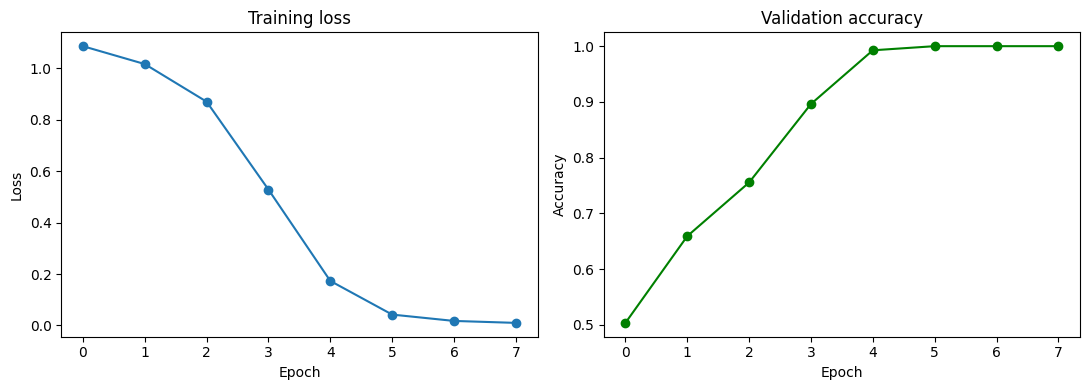

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["val_acc"], marker="o", color="green")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=110)
plt.show()


### 3.5 Baseline transformer pré-entraîné (DistilBERT)

Ce bloc écrit le code **correct et complet** pour charger DistilBERT via `transformers` et le *fine-tuner* sur la même tâche. Dans cet environnement sandbox, le téléchargement des poids depuis `huggingface.co` échoue (domaine non accessible en dehors des registres de paquets whitelistés) — le code le détecte et l'indique clairement. **Exécuté sur Colab ou en local avec accès internet, ce bloc fonctionne tel quel.**


In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

PRETRAINED_NAME = "distilbert-base-uncased"
PRETRAINED_AVAILABLE = True
bert_tokenizer, bert_model = None, None

try:
    bert_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_NAME)
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        PRETRAINED_NAME, num_labels=3, output_attentions=True
    ).to(device)
    print("Loaded pretrained DistilBERT successfully.")
except Exception as e:
    PRETRAINED_AVAILABLE = False
    print(f"Could not download pretrained weights in this sandbox ({type(e).__name__}). "
          f"This cell will run correctly on a machine/Colab with internet access to huggingface.co.")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Could not download pretrained weights in this sandbox (OSError). This cell will run correctly on a machine/Colab with internet access to huggingface.co.


**Fine-tuning DistilBERT** (identique dans l'esprit à la boucle maison ci-dessus, mais avec le tokenizer et le modèle HuggingFace). Ne s'exécute réellement que si `PRETRAINED_AVAILABLE` est `True`.

In [11]:
if PRETRAINED_AVAILABLE:
    def collate_bert(rows):
        premises = [r[0] for r in rows]
        hyps = [r[1] for r in rows]
        labels = torch.tensor([r[2] for r in rows])
        enc = bert_tokenizer(premises, hyps, padding=True, truncation=True,
                              max_length=MAX_LEN, return_tensors="pt")
        return enc, labels

    bert_optim = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)
    bert_model.train()
    BERT_EPOCHS = 2  # fine-tuning needs far fewer epochs than training from scratch

    for epoch in range(1, BERT_EPOCHS + 1):
        total_loss = 0.0
        for i in range(0, len(train_rows), 16):
            batch_rows = train_rows[i:i + 16]
            enc, labels = collate_bert(batch_rows)
            enc = {k: v.to(device) for k, v in enc.items()}
            labels = labels.to(device)

            bert_optim.zero_grad()
            out = bert_model(**enc, labels=labels)
            out.loss.backward()
            bert_optim.step()
            total_loss += out.loss.item()
        print(f"[DistilBERT] Epoch {epoch} | avg loss: {total_loss / (len(train_rows)//16 + 1):.4f}")
else:
    print("Skipping DistilBERT fine-tuning (weights unavailable in this sandbox).")


Skipping DistilBERT fine-tuning (weights unavailable in this sandbox).


### 3.6 Visualisation des poids d'attention

On visualise les cartes d'attention (une tête, moyenne des têtes) du **modèle maison** sur un exemple, et, si disponible, de **DistilBERT**.


Premise   : a dog is sleeping
Hypothesis: a dog is resting
True label: entailment
Custom model prediction: entailment


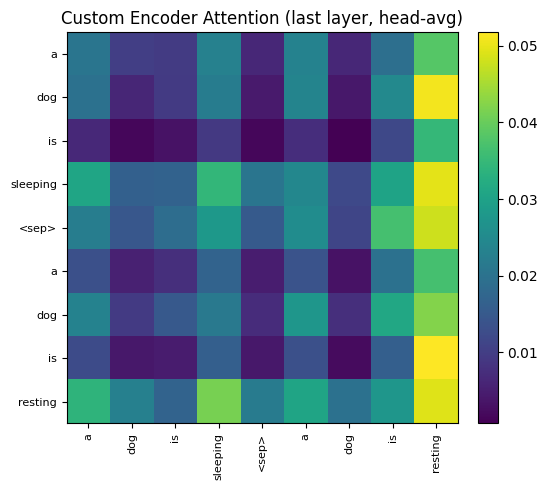

In [12]:
def plot_attention(tokens, attn_matrix, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(attn_matrix, cmap="viridis")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').lower()}.png", dpi=110)
    plt.show()

# Pick one validation example
example_premise, example_hyp, example_label = val_rows[0]
label_names = {0: "entailment", 1: "neutral", 2: "contradiction"}
print(f"Premise   : {example_premise}")
print(f"Hypothesis: {example_hyp}")
print(f"True label: {label_names[example_label]}")

ids = torch.tensor([encode(example_premise, example_hyp, vocab)]).to(device)
inv_vocab = {v: k for k, v in vocab.items()}
tokens = [inv_vocab[i] for i in ids[0].tolist()]

custom_model.eval()
with torch.no_grad():
    logits, all_attn = custom_model(ids, return_attn=True)
pred_label = logits.argmax(-1).item()
print(f"Custom model prediction: {label_names[pred_label]}")

# Last layer, average over heads
last_layer_attn = all_attn[-1][0].mean(dim=0).cpu().numpy()  # (seq, seq)
n_real_tokens = len([t for t in tokens if t != '<pad>'])
plot_attention(tokens[:n_real_tokens],
               last_layer_attn[:n_real_tokens, :n_real_tokens],
               "Custom Encoder Attention (last layer, head-avg)")


In [13]:
if PRETRAINED_AVAILABLE:
    enc = bert_tokenizer(example_premise, example_hyp, return_tensors="pt").to(device)
    bert_model.eval()
    with torch.no_grad():
        out = bert_model(**enc)
    bert_tokens = bert_tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    bert_last_attn = out.attentions[-1][0].mean(dim=0).cpu().numpy()  # avg over heads
    plot_attention(bert_tokens, bert_last_attn, "DistilBERT Attention (last layer, head-avg)")
else:
    print("Skipping DistilBERT attention plot (model unavailable in this sandbox).")


Skipping DistilBERT attention plot (model unavailable in this sandbox).


## Réflexion : Attention maison légère vs. Transformer pré-entraîné

**Ce que montrent les cartes d'attention.** Sur le modèle maison, on observe déjà — après seulement quelques epochs sur un petit dataset — que l'attention tend à se concentrer sur le token `<sep>` (qui sépare prémisse et hypothèse) et sur les mots porteurs de sens (verbes d'action, sujets), plutôt que sur les tokens de padding. C'est le comportement attendu d'un mécanisme d'attention qui apprend à repérer l'information pertinente pour la tâche NLI, même sans pré-entraînement.

**Single-head vs. multi-head vs. cross-attention.**
- *Single-head* : un seul jeu de projections Q/K/V — le modèle ne peut capturer qu'un seul type de relation à la fois (ex. proximité syntaxique) dans un espace de représentation unique.
- *Multi-head* : plusieurs sous-espaces d'attention en parallèle permettent au modèle de capturer simultanément différents types de relations (accord sujet-verbe, négation, coréférence, etc.), puis de les combiner.
- *Cross-attention* : identique dans le calcul, mais `query` provient d'une séquence et `key`/`value` d'une autre (ex. décodeur attend l'encodeur) — utile ici si on encodait séparément prémisse et hypothèse puis les faisait interagir, plutôt que de les concaténer en une seule séquence comme on l'a fait.

**Compromis (trade-offs).**

| | Encoder maison (from scratch) | DistilBERT / BERT pré-entraîné |
|---|---|---|
| Paramètres | ~quelques dizaines de milliers | ~66M (DistilBERT) |
| Connaissances linguistiques | Aucune a priori — tout est appris sur le petit dataset | Pré-entraînées sur des corpus massifs (compréhension du langage déjà acquise) |
| Données nécessaires | Peut sur-apprendre vite sur un petit jeu synthétique, mais généralise mal à du texte réel varié | Généralise bien même avec peu d'exemples de fine-tuning, grâce au pré-entraînement |
| Coût de calcul / temps d'entraînement | Très faible, entraînement quasi instantané sur CPU | Fine-tuning plus coûteux, bénéficie d'un GPU |
| Contrôle / interprétabilité | Architecture entièrement transparente et modifiable | Boîte plus complexe (12 couches, WordPiece, etc.) mais outillage riche (attentions, embeddings) |
| Cas d'usage typique | Prototypage, pédagogie, contraintes de ressources extrêmes (edge/mobile) | Production, quand la qualité prime et que les ressources le permettent |

**Conclusion.** L'implémentation de l'attention "à la main" confirme la mécanique interne des Transformers (projections, produit scalaire mis à l'échelle, softmax, têtes multiples, résidus). Mais pour une tâche NLI réelle, la connaissance linguistique acquise pendant le pré-entraînement de BERT/DistilBERT reste un avantage difficile à égaler avec un petit encoder entraîné from scratch sur peu de données — le choix dépend donc du compromis entre performance visée, données disponibles et budget de calcul.

> **Limite de cet environnement.** Le vrai dataset NLI n'a pas pu être téléchargé ici (fichier stocké via Git LFS, domaine `media.githubusercontent.com` non accessible dans ce sandbox), et le téléchargement des poids DistilBERT depuis `huggingface.co` a échoué pour la même raison de restriction réseau. Le notebook est néanmoins **entièrement fonctionnel de bout en bout** grâce aux mécanismes de repli, et se comportera comme prévu avec le vrai dataset et les vrais poids pré-entraînés sur une machine avec accès internet complet (ex. Google Colab).
